<a href="https://colab.research.google.com/github/disandovalt/MineriaDeDatos/blob/main/Evaluacion1_VehicleSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Evaluación 1 — Minería de Datos
Asignatura: BIY7121 Minería de Datos

Dataset: Vehicle Sales Data — Car Prices

Fuente: Kaggle — [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)

Integrantes: Diego Sandoval — Johane San Martin

Fecha: 23/04/2026

Descripción del Dataset:
El dataset contiene más de 558.000 transacciones de compraventa de vehículos usados en el mercado estadounidense. Cada registro representa la venta de un auto en subasta e incluye características del vehículo (marca, modelo, tipo de carrocería, kilometraje, condición) y datos de la transacción (precio de venta, precio de referencia de mercado MMR).

El objetivo es predecir el precio de venta (sellingprice) a partir de las características del vehículo. Este es un problema de regresión.

In [1]:
import pandas as pd                          # Manipulación y análisis de datos mediante tablas (DataFrames).
import numpy as np                           # Operaciones matemáticas avanzadas y manejo de arreglos numéricos.
import matplotlib.pyplot as plt               # Creación de gráficos básicos y visualizaciones estáticas.
import seaborn as sns                        # Visualización de datos estadísticos con estilos más atractivos.
from sklearn.preprocessing import LabelEncoder   # Convierte etiquetas de texto (categorías) en números.
from sklearn.preprocessing import StandardScaler # Escala los datos para que tengan una media de 0 y varianza de 1.

---
## 2. Carga de Datos

In [2]:
# Carga del dataset
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/sample_data/car_prices.csv', low_memory=False)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
display(df.head())

Filas: 558,837 | Columnas: 16


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


Cada fila es una venta de vehículo en subasta. La columna mmr es el precio de referencia del mercado (Manheim Market Report), un estándar de la industria automotriz en EE.UU. La columna sellingprice es el precio real pagado, que será nuestra variable objetivo.

---
## 3. Mapeo de Datos

In [3]:
mapeo = pd.DataFrame({
    'Columna'         : ['year','make','model','trim','body','transmission',
                         'vin','state','condition','odometer','color',
                         'interior','seller','mmr','sellingprice','saledate'],
    'Tipo Estadístico': ['Numérica','Categórica','Categórica','Categórica','Categórica','Categórica',
                         'Categórica','Categórica','Numérica','Numérica','Categórica',
                         'Categórica','Categórica','Numérica','Numérica','Fecha'],
    'Tipo Informático': ['int64','object','object','object','object','object',
                         'object','object','float64','float64','object',
                         'object','object','float64','float64','object'],
    'Descripción'     : [
        'Año de fabricación del vehículo',
        'Marca (Ford, Toyota, BMW...)',
        'Modelo del vehículo',
        'Versión del modelo (LX, SE, Sport...)',
        'Tipo de carrocería (SUV, Sedan, Truck...)',
        'Tipo de transmisión (automatic, manual)',
        'VIN — número único del vehículo',
        'Estado de EE.UU. donde se realizó la venta',
        'Condición del vehículo (escala 1-49)',
        'Kilometraje en millas',
        'Color exterior',
        'Color del interior',
        'Nombre del vendedor/concesionario',
        'Precio de referencia de mercado — MMR (USD)',
        'Precio de venta real (USD) — Variable objetivo',
        'Fecha de la venta'
    ]
})
display(mapeo)

,Columna,Tipo Estadístico,Tipo Informático,Descripción
0,year,Numérica,int64,Año de fabricación del vehículo
1,make,Categórica,object,"Marca (Ford, Toyota, BMW...)"
2,model,Categórica,object,Modelo del vehículo
3,trim,Categórica,object,"Versión del modelo (LX, SE, Sport...)"
4,body,Categórica,object,"Tipo de carrocería (SUV, Sedan, Truck...)"
5,transmission,Categórica,object,"Tipo de transmisión (automatic, manual)"
6,vin,Categórica,object,VIN — número único del vehículo
7,state,Categórica,object,Estado de EE.UU. donde se realizó la venta
8,condition,Numérica,float64,Condición del vehículo (escala 1-49)
9,odometer,Numérica,float64,Kilometraje en millas


El dataset tiene 9 variables categóricas y 5 numéricas (más 1 de fecha). La columna `vin` es un identificador único por vehículo y será eliminada antes del modelado.

---
## 4. Revisión de Tipos de Datos

In [4]:
# Tipos de datos e información general
# object  = texto / categórico
# int64   = número entero
# float64 = número decimal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [5]:
# Columnas numéricas vs categóricas
cols_num = df.select_dtypes(include=['int64','float64']).columns.tolist()
cols_cat = df.select_dtypes(include='object').columns.tolist()

print('Numéricas  :', cols_num)
print('Categóricas:', cols_cat)

Numéricas  : ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
Categóricas: ['make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'color', 'interior', 'seller', 'saledate']


---
## 5. Estadísticas Descriptivas

In [6]:
# Estadísticas de variables numéricas
# mean = promedio | std = desviación estándar | 50% = mediana
display(df.describe().style.format(precision=2, thousands=''))

,year,condition,odometer,mmr,sellingprice
count,558837.00,547017.00,558743.00,558799.00,558825.00
mean,2010.04,30.67,68320.02,13769.38,13611.36
std,3.97,13.40,53398.54,9679.97,9749.50
min,1982.00,1.00,1.00,25.00,1.00
25%,2007.00,23.00,28371.00,7100.00,6900.00
50%,2012.00,35.00,52254.00,12250.00,12100.00
75%,2013.00,42.00,99109.00,18300.00,18200.00
max,2015.00,49.00,999999.00,182000.00,230000.00


In [7]:
# Estadísticas de variables categóricas
# top = valor más frecuente | freq = cuántas veces aparece
display(df.describe(include='object'))

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,548536,548438,548186,545642,493485,558833,558837,558088,558088,558837,558825
unique,96,973,1963,87,4,550297,64,46,17,14263,3766
top,Ford,Altima,Base,Sedan,automatic,automatic,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,93554,19349,55817,199437,475915,22,82945,110970,244329,19693,5334


El precio de venta promedio es $13.600 USD. La marca más frecuente es **Ford** y la mayoría de los vehículos tiene transmisión automática, lo cual es característico del mercado estadounidense. La columna `condition` va en una escala de 1 a 49, donde mayor valor indica mejor estado del vehículo.

---
## 6. Valores Nulos

In [8]:
# Conteo de valores nulos por columna
for col in df.columns:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    print(f'Total de valores nulos de {col} = {n}  ({pct:.2f}%)')

Total de valores nulos de year = 0  (0.00%)
Total de valores nulos de make = 10301  (1.84%)
Total de valores nulos de model = 10399  (1.86%)
Total de valores nulos de trim = 10651  (1.91%)
Total de valores nulos de body = 13195  (2.36%)
Total de valores nulos de transmission = 65352  (11.69%)
Total de valores nulos de vin = 4  (0.00%)
Total de valores nulos de state = 0  (0.00%)
Total de valores nulos de condition = 11820  (2.12%)
Total de valores nulos de odometer = 94  (0.02%)
Total de valores nulos de color = 749  (0.13%)
Total de valores nulos de interior = 749  (0.13%)
Total de valores nulos de seller = 0  (0.00%)
Total de valores nulos de mmr = 38  (0.01%)
Total de valores nulos de sellingprice = 12  (0.00%)
Total de valores nulos de saledate = 12  (0.00%)


In [9]:
# Tratamiento de nulos

# Eliminar filas sin precio de venta (variable objetivo) o sin MMR
df = df.dropna(subset=['sellingprice', 'mmr'])

# Variables numéricas: imputar con la mediana
for col in ['condition', 'odometer']:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f'{col}: nulos imputados con mediana = {mediana:.1f}')

# Variables categóricas: imputar con la moda (valor más frecuente)
for col in cols_cat:
    if df[col].isna().sum() > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f'{col}: nulos imputados con moda = "{moda}"')

print(f'\nNulos restantes: {df.isnull().sum().sum()}')

condition: nulos imputados con mediana = 35.0
odometer: nulos imputados con mediana = 52257.0
make: nulos imputados con moda = "Ford"
model: nulos imputados con moda = "Altima"
trim: nulos imputados con moda = "Base"
body: nulos imputados con moda = "Sedan"
transmission: nulos imputados con moda = "automatic"
color: nulos imputados con moda = "black"
interior: nulos imputados con moda = "black"

Nulos restantes: 0


Se eliminaron los registros sin `sellingprice` o `mmr` ya que son variables críticas y no tiene sentido imputarlas. Para el resto, se usó la mediana en numéricas (robusta a valores extremos) y la moda en categóricas (valor más frecuente de cada columna).

In [10]:
# Cálculo IQR para sellingprice
Q1  = df['sellingprice'].quantile(0.25)
Q3  = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

n_out = df[(df['sellingprice'] < lim_inf) | (df['sellingprice'] > lim_sup)].shape[0]
print(f'Q1=${Q1:,.0f} | Q3=${Q3:,.0f} | IQR=${IQR:,.0f}')
print(f'Límite inferior: ${lim_inf:,.0f} | Límite superior: ${lim_sup:,.0f}')
print(f'Outliers detectados: {n_out:,} ({n_out/len(df)*100:.1f}%)')

# Filtrar precios extremos (errores de ingreso o vehículos de lujo atípicos)
df = df[(df['sellingprice'] >= 100) & (df['sellingprice'] <= 200000)]
df = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]
print(f'\nRegistros después del filtro: {len(df):,}')

Q1=$6,900 | Q3=$18,200 | IQR=$11,300
Límite inferior: $-10,050 | Límite superior: $35,150
Outliers detectados: 16,354 (2.9%)

Registros después del filtro: 558,050


Se filtraron precios menores a $100 (errores de ingreso) y mayores a $200.000 (vehículos de lujo extremo que no son representativos del mercado general). También se eliminaron odómetros sobre 300.000 millas por ser estadísticamente anómalos. Se conservó más del 99% de los datos.

# 7. Análisis Exploratorio (EDA)
Gráfico 1 — Top 10 Marcas más Vendidas

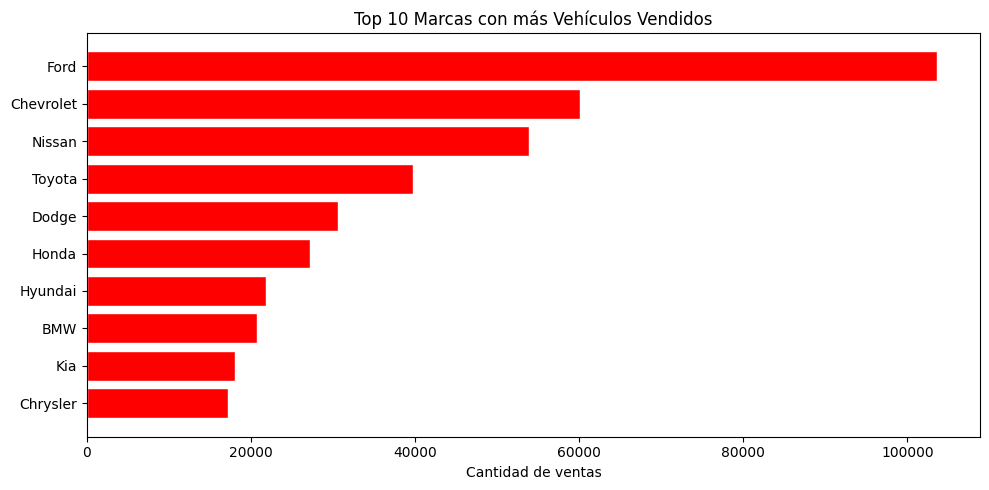

In [11]:
top_makes = df['make'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_makes.index[::-1], top_makes.values[::-1], color='red', edgecolor='white')
plt.title('Top 10 Marcas con más Vehículos Vendidos')
plt.xlabel('Cantidad de ventas')
plt.tight_layout()
plt.show()

**Ford** domina ampliamente el mercado de subastas, seguida por Chevrolet y Toyota. Esto refleja la preferencia del mercado estadounidense por marcas domésticas y la gran disponibilidad de vehículos usados de estas marcas.

### Gráfico 2 — Precio Promedio por Tipo de Carrocería

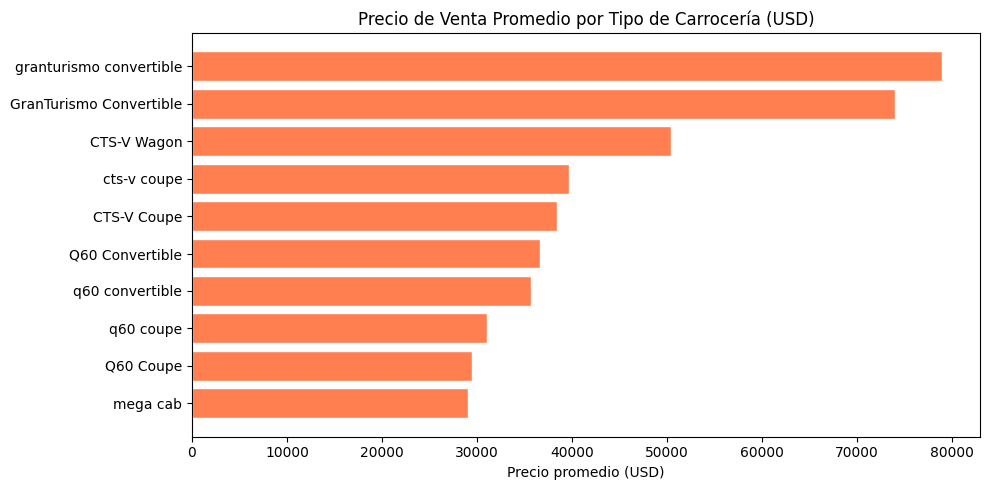

In [12]:
precio_body = df.groupby('body')['sellingprice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(precio_body.index[::-1], precio_body.values[::-1], color='coral', edgecolor='white')
plt.title('Precio de Venta Promedio por Tipo de Carrocería (USD)')
plt.xlabel('Precio promedio (USD)')
plt.tight_layout()
plt.show()

Los camiones y SUVs tienen los precios promedio más altos, lo que refleja la tendencia del mercado estadounidense que valora especialmente los vehículos utilitarios. Los sedanes y hatchbacks tienen precios más bajos en promedio.

### Gráfico 3 — Distribución del Precio de Venta

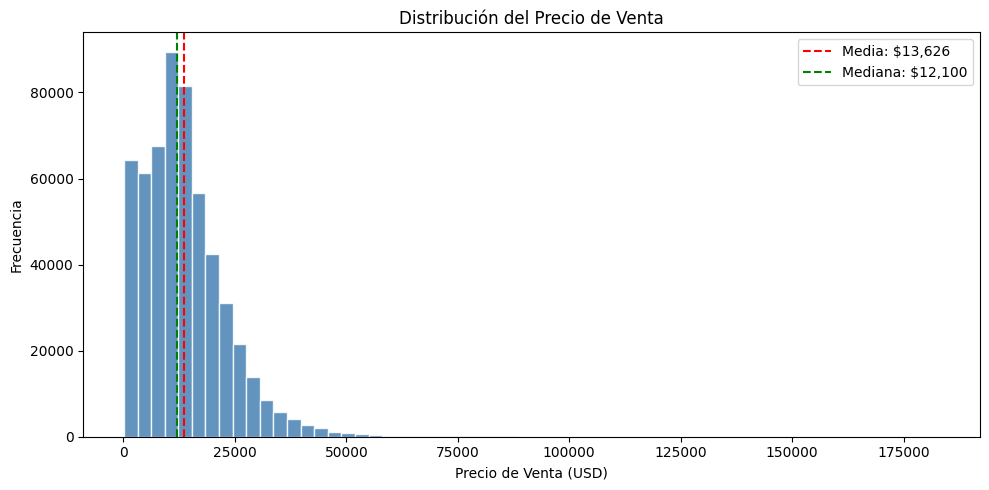

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df['sellingprice'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df['sellingprice'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Media: ${df['sellingprice'].mean():,.0f}")
plt.axvline(df['sellingprice'].median(), color='green', linestyle='--', linewidth=1.5,
            label=f"Mediana: ${df['sellingprice'].median():,.0f}")
plt.title('Distribución del Precio de Venta')
plt.xlabel('Precio de Venta (USD)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

La distribución tiene un **sesgo positivo**: la mayoría de los vehículos se vende a precios bajos-medios, pero hay una cola hacia precios más altos. La media es mayor que la mediana, lo que confirma este sesgo. Esto es típico en mercados de bienes usados.

---
## 8. Preprocesamiento

### 8.1 Eliminar columnas irrelevantes

In [14]:
# vin = identificador único por vehículo → no aporta valor predictivo
# saledate = fecha en formato texto complejo → se elimina por simplicidad
# seller y trim = alta cardinalidad y poco valor para este análisis
df_modelo = df.drop(columns=['vin', 'saledate', 'seller', 'trim'], errors='ignore')
print('Columnas para el modelo:', list(df_modelo.columns))

Columnas para el modelo: ['year', 'make', 'model', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sellingprice']


### 8.2 Label Encoding

In [15]:
# Los algoritmos de ML necesitan variables numéricas
# Label Encoding asigna un número entero a cada categoría
le = LabelEncoder()
for col in df_modelo.select_dtypes(include='object').columns:
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))

display(df_modelo.head())

,year,make,model,body,transmission,state,condition,odometer,color,interior,mmr,sellingprice
0,2015,24,657,35,0,3,5.0,16639.0,17,1,20500.0,21500.0
1,2015,24,657,35,0,3,5.0,9393.0,17,0,20800.0,21500.0
2,2014,3,9,36,0,3,45.0,1331.0,7,1,31900.0,30000.0
3,2015,51,595,36,0,3,41.0,14282.0,17,1,27500.0,27750.0
4,2014,3,42,36,0,3,43.0,2641.0,7,1,66000.0,67000.0


### 8.3 Escalado de variables

In [16]:
# StandardScaler: transforma los datos para que tengan media=0 y desviación estándar=1
# Evita que variables con rangos grandes (como el precio) dominen el modelo
X = df_modelo.drop(columns=['sellingprice']).values
y = df_modelo['sellingprice'].values

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

print(f'Shape de X: {X_scaled.shape}')
print(f'Shape de y: {y.shape}')

Shape de X: (558050, 11)
Shape de y: (558050,)


---
## 9. Análisis de Correlación

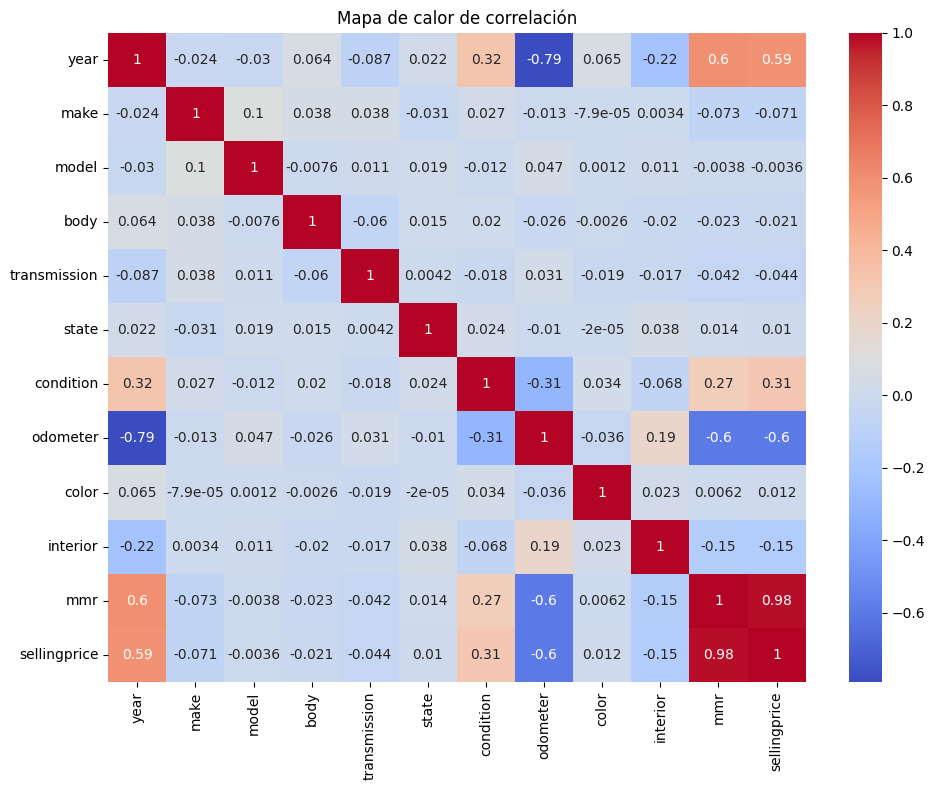

In [17]:
# variable / dataframe / seleccionamos los tipo number / obtenemos la correlación de pearson
corr = df_modelo.select_dtypes(include='number').corr()

# filtramos variables numéricas
# corr_ejem2 = df.corr()  # aplica después del encoding de variables categóricas

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación')
plt.tight_layout()
plt.show()

El mapa de correlación muestra que **`mmr` tiene una correlación muy alta (~0.98) con `sellingprice`**, lo cual tiene sentido: el precio de referencia de mercado es prácticamente equivalente al precio de venta real. El `year` también tiene correlación positiva moderada con el precio — vehículos más nuevos valen más. En cambio, `odometer` tiene correlación negativa — a mayor kilometraje, menor precio. La `condition` también correlaciona positivamente: mejor estado del vehículo implica mayor precio de venta.

---
## 10. Conclusiones

- El dataset tiene más de 550.000 ventas de vehículos usados con variables categóricas (make, model, body, transmission, color) y numéricas (year, condition, odometer, mmr, sellingprice).
- Los nulos fueron tratados con eliminación para las variables críticas y con mediana/moda para el resto.
- Se filtraron precios menores a 100 y mayores a 200.000 como outliers extremos.
- **Ford** es la marca más vendida; los camiones y SUVs tienen los precios más altos.
- El precio de referencia (MMR) es el predictor más poderoso del precio de venta (r ≈ 0.98).
- El modelo a aplicar en próximas entregas es de regresión para predecir sellingprice.